In [73]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [74]:
df=pd.read_csv('weatherAUS.csv', low_memory = False)
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [75]:
df.isnull().mean()*100

Date              0.000000
Location          0.000000
MinTemp           1.020899
MaxTemp           0.866905
Rainfall          2.241853
Evaporation      43.166506
Sunshine         48.009762
WindGustDir       7.098859
WindGustSpeed     7.055548
WindDir9am        7.263853
WindDir3pm        2.906641
WindSpeed9am      1.214767
WindSpeed3pm      2.105046
Humidity9am       1.824557
Humidity3pm       3.098446
Pressure9am      10.356799
Pressure3pm      10.331363
Cloud9am         38.421559
Cloud3pm         40.807095
Temp9am           1.214767
Temp3pm           2.481094
RainToday         2.241853
RainTomorrow      2.245978
dtype: float64

In [76]:
print(df['RainTomorrow'].value_counts())
print(df['RainToday'].value_counts())
print(df.shape)
df.drop('Date',axis=1, inplace=True)
df

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64
RainToday
No     110319
Yes     31880
Name: count, dtype: int64
(145460, 23)


,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [77]:
df.fillna(df.mean(numeric_only=True),inplace=True)
df.fillna(df.mode(numeric_only=False).iloc[0], inplace=True)

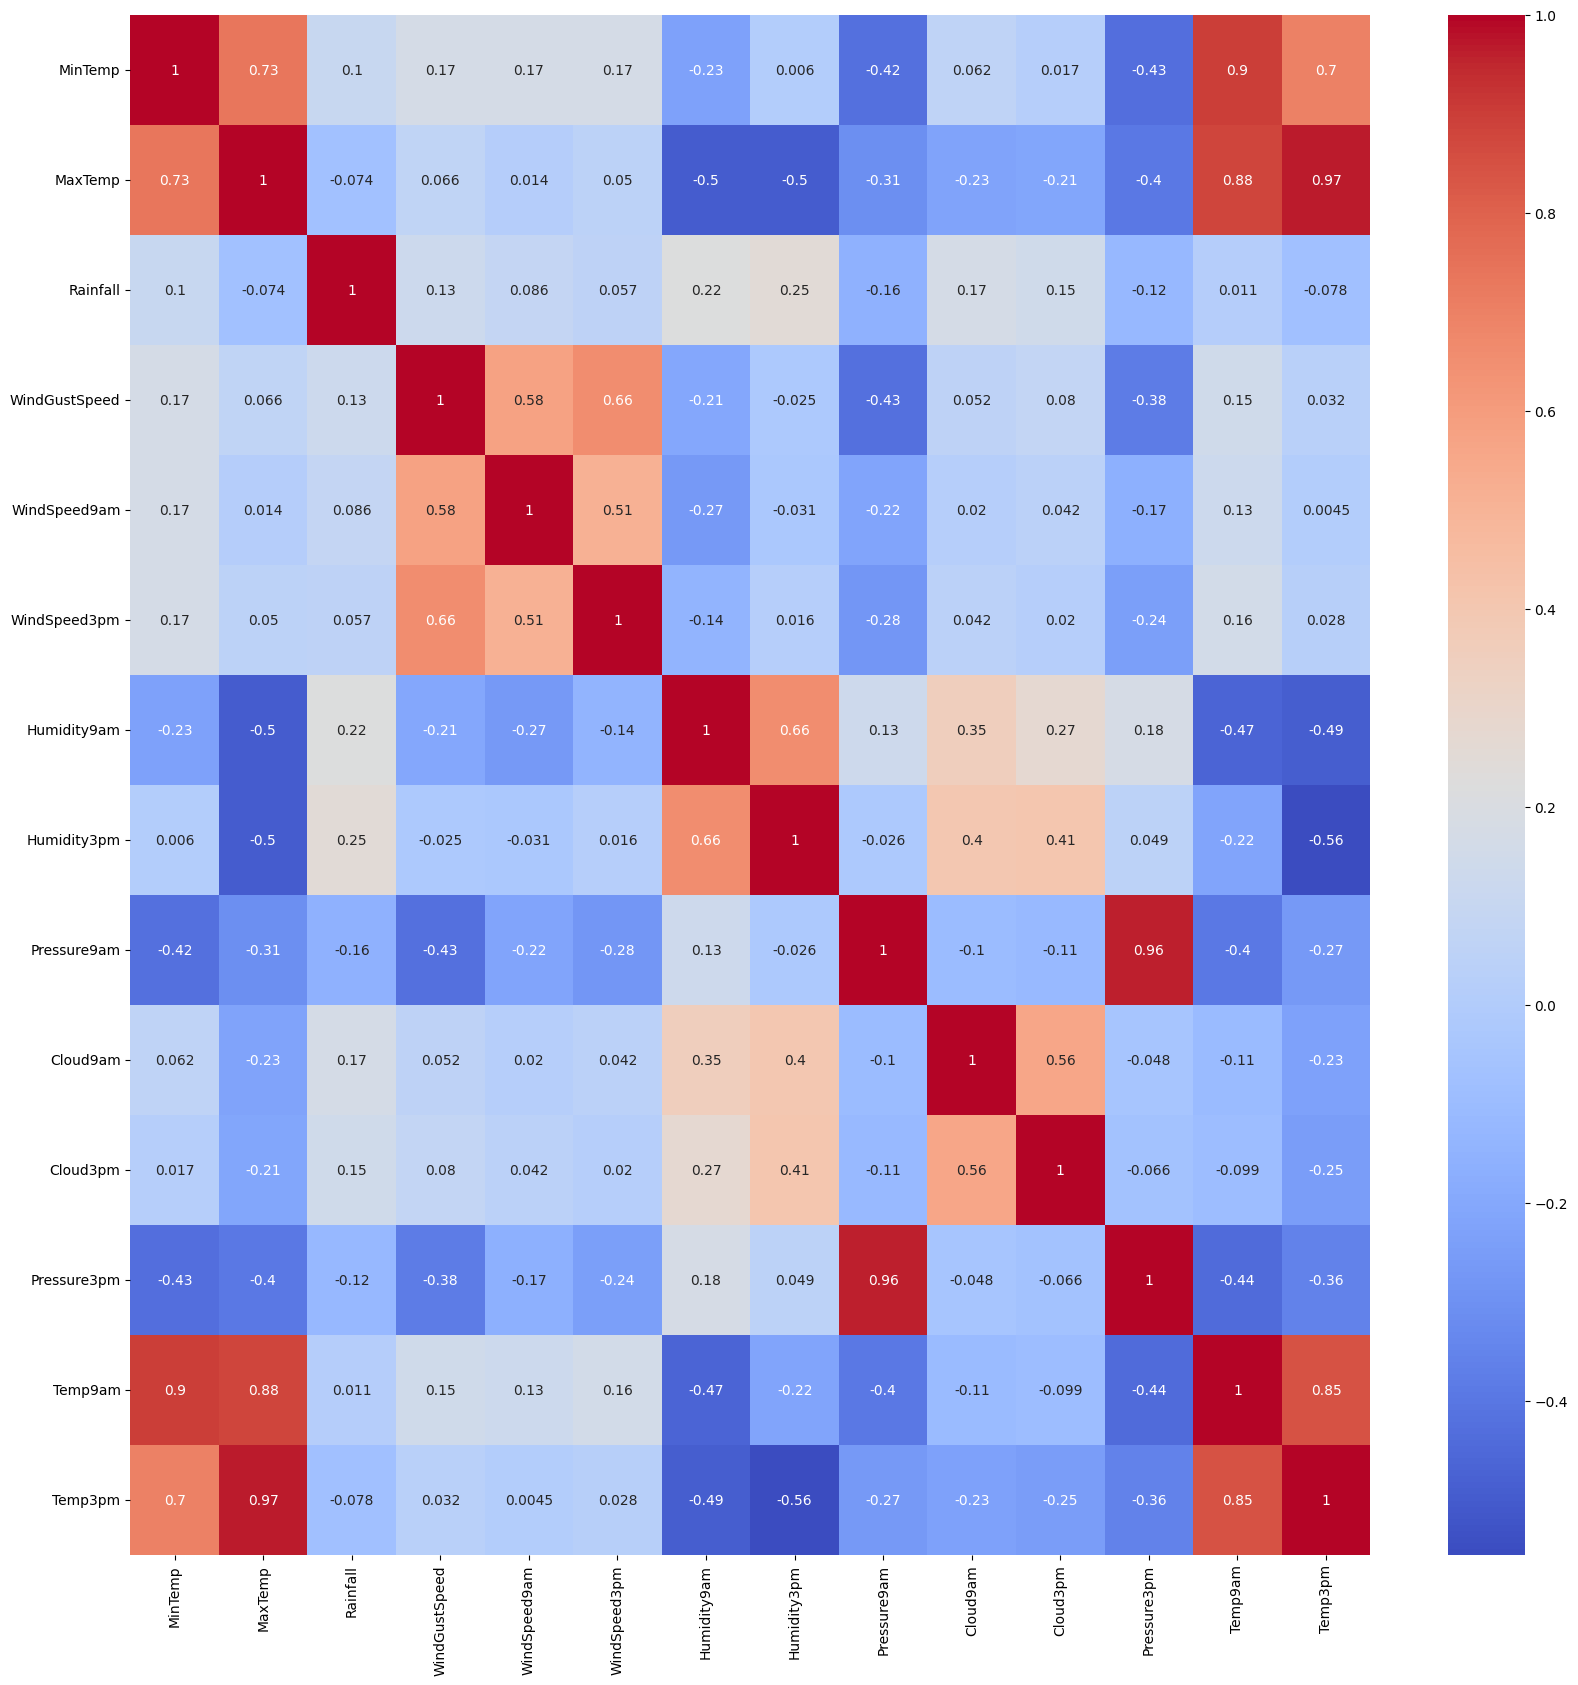

In [78]:
plt.figure(figsize=(20,20))
df0=df[['MinTemp','MaxTemp','Rainfall','WindGustSpeed','WindSpeed9am',
        'WindSpeed3pm','Humidity9am','Humidity3pm','Pressure9am','Cloud9am','Cloud3pm','Pressure3pm','Temp9am','Temp3pm']]
corr_matrix = df0.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

In [79]:
df1=pd.get_dummies(df, drop_first=True, dtype=int)
df1

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,RainToday_Yes,RainTomorrow_Yes
0,13.4,22.900000,0.6,5.468232,7.611178,44.00000,20.0,24.0,71.0,22.0,...,0,0,0,0,0,0,1,0,0,0
1,7.4,25.100000,0.0,5.468232,7.611178,44.00000,4.0,22.0,44.0,25.0,...,0,0,0,0,0,0,0,1,0,0
2,12.9,25.700000,0.0,5.468232,7.611178,46.00000,19.0,26.0,38.0,30.0,...,0,0,0,0,0,0,0,1,0,0
3,9.2,28.000000,0.0,5.468232,7.611178,24.00000,11.0,9.0,45.0,16.0,...,0,0,0,0,0,0,0,0,0,0
4,17.5,32.300000,1.0,5.468232,7.611178,41.00000,7.0,20.0,82.0,33.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.400000,0.0,5.468232,7.611178,31.00000,13.0,11.0,51.0,24.0,...,0,0,0,0,0,0,0,0,0,0
145456,3.6,25.300000,0.0,5.468232,7.611178,22.00000,13.0,9.0,56.0,21.0,...,0,0,0,0,0,0,0,0,0,0
145457,5.4,26.900000,0.0,5.468232,7.611178,37.00000,9.0,9.0,53.0,24.0,...,0,0,0,0,0,0,1,0,0,0
145458,7.8,27.000000,0.0,5.468232,7.611178,28.00000,13.0,7.0,51.0,24.0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
cols=['MinTemp','MaxTemp','Evaporation','Rainfall','WindGustSpeed']
dfc=df1.copy()
for col in cols:
    
    Q1=dfc[col].quantile(0.25)
    Q3=dfc[col].quantile(0.75)
    IQR=Q3-Q1
    
    lb=Q1-1.5*IQR
    up=Q3+1.5*IQR
    
    df2=dfc[(dfc[col]>=lb) & (dfc[col]<=up)].copy()# & because it checks element wise not and because it checks column wise
    print(len(df1),len(df2))

145460 145378
145460 144916
145460 115829
145460 121737
145460 139937


In [81]:
df2.shape

(139937, 111)

In [82]:
# eaier to predict value by checking if the value is negative then there are more chances of rain
df2['Pressure_Change'] = df2['Pressure3pm'] - df2['Pressure9am']
df2['Pressure_Crash'] = (df2['Pressure_Change'] < -3).astype(int)
df2['Temp_Change'] = df2['Temp3pm'] - df2['Temp9am']

df2['Humid_Pressure_Risk'] = df2['Humidity3pm'] * df2['Pressure_Change']
# The gap between morning and afternoon is a huge indicator
df2['Humidity_Trend'] = df2['Humidity3pm'] - df2['Humidity9am']
df2['Temp_Spread'] = df2['MaxTemp'] - df2['MinTemp'] 

# Wind Gust Ratio (Sudden spikes in wind vs steady wind)
df2['Wind_Burst'] = df2['WindGustSpeed'] / (df2['WindSpeed3pm'] + 1)

In [114]:
#shuffling to make sure that the split is random and not biased
df_shuffled=df2.sample(frac=1, random_state=42).reset_index(drop=True)
# frac gives back all the data , random makes sure that the order in which its getting randomised is the same
split=0.8
n=int(len(df_shuffled)*split)

correlations = df2.corr()['RainTomorrow_Yes'].abs().sort_values(ascending=False)

best_features = correlations[correlations > 0.05].index.tolist()

train=df_shuffled.iloc[:n]
test=df_shuffled.iloc[n:]
X_train=train[best_features].drop(['RainTomorrow_Yes'], axis=1)
y_train=train['RainTomorrow_Yes']

X_test=test[best_features].drop('RainTomorrow_Yes', axis=1)
y_test=test['RainTomorrow_Yes']

print('total rows:',len(df))
print('Train rows:',len(X_train))
print('Test rows:',len(X_test))

total rows: 145460
Train rows: 111949
Test rows: 27988


In [115]:
#Min-Max Scaling
num_cols=X_train.select_dtypes(include=['number']).columns # selecting only numeric columns
X_train_scaled=(X_train[num_cols]-X_train[num_cols].min())/(X_train[num_cols].max()-X_train[num_cols].min())
X_test_scaled=(X_test[num_cols]-X_train[num_cols].min())/(X_train[num_cols].max()-X_train[num_cols].min()) 
#to prevent data leakage we use train max and min values

In [116]:
import numpy as np
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

feature=X_train_scaled.shape[1]
w=np.zeros(feature)
b=0

In [117]:
#gradient descent
iter=2000
alpha=0.1

# It is also safer to convert them to numpy arrays to avoid pandas indexing issues in the loop
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

#if this shows any error its prolly because the numpy array lost its pandas properties as map is a function in pandas so the 
#remedy is going back to the line where i declared the test and train set and re running it

costs=[] #for the cost function
n=len(y_train)
feature = X_train_scaled.shape[1]
w = np.zeros(feature)
b = 0

for i in range(iter):
    z=np.dot(X_train_scaled ,w)+b
    predict=sigmoid(z)
    predict = np.clip(predict, 1e-15, 1 - 1e-15)#clip makes sure that the value doesnt go out of the range
# if its bigger it becomes equal to 1 - 1e-15 aand if its smaller it becomes 1e-15
    
    error = (predict - y_train)

    loss = (-1/n) * np.sum(y_train * np.log(predict) + (1 - y_train) * np.log(1 - predict))
    #this is our loss function which we calculate for each property
    costs.append(loss)
    
    dw = (1 / n) * np.dot(X_train_scaled.T, error)
    db = (1 / n) * np.sum(error)
    
    w-=alpha*dw
    b-=alpha*db

    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {loss}")

Iteration 0: Cost = 0.6931471805599452
Iteration 100: Cost = 0.4652515043707665
Iteration 200: Cost = 0.43761737453635446
Iteration 300: Cost = 0.4215008143563976
Iteration 400: Cost = 0.4109299890093924
Iteration 500: Cost = 0.40333969613886145
Iteration 600: Cost = 0.3975392278222972
Iteration 700: Cost = 0.3929188282258269
Iteration 800: Cost = 0.38913356845732816
Iteration 900: Cost = 0.38597013495201465
Iteration 1000: Cost = 0.3832866706281719
Iteration 1100: Cost = 0.3809834590848402
Iteration 1200: Cost = 0.3789874681971939
Iteration 1300: Cost = 0.37724355651037494
Iteration 1400: Cost = 0.3757091172075557
Iteration 1500: Cost = 0.3743506240835016
Iteration 1600: Cost = 0.37314130019670616
Iteration 1700: Cost = 0.3720594873964979
Iteration 1800: Cost = 0.37108747407681486
Iteration 1900: Cost = 0.3702106337763072


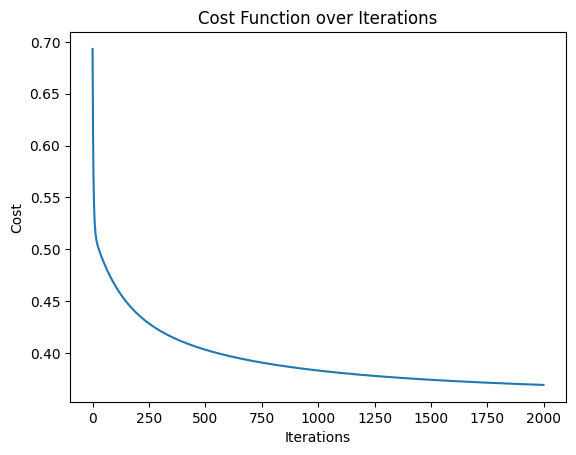

In [118]:
plt.plot(costs)
plt.title("Cost Function over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()

In [119]:
z_test = np.dot(X_test_scaled, w) + b
test_probs = sigmoid(z_test)

# Convert to 0 or 1
y_final_pred = [1 if p >= 0.5 else 0 for p in test_probs]

In [137]:
correct_guesses = sum(y_final_pred == y_test)
accuracy = (correct_guesses / len(y_test)) * 100
print(f"Testing accuracy: {accuracy}%")

Testing accuracy: 83.83950264399029%


In [138]:
# Convert y_final_pred to numpy for comparison
y_test = np.array(y_test)
y_pred = np.array(y_final_pred)

# 1. Calculate components
tp = np.sum((y_pred == 1) & (y_test == 1)) # True Positives
fp = np.sum((y_pred == 1) & (y_test == 0)) # False Positives
fn = np.sum((y_pred == 0) & (y_test == 1)) # False Negatives

# 2. Calculate Precision and Recall
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# 3. Calculate F1 Score
if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0

print("--- Evaluation Results test data (Without SMOTE) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

--- Evaluation Results test data (Without SMOTE) ---
Precision: 0.7260
Recall: 0.3624
F1 Score: 0.4835


In [139]:
# 1. Generate predictions for the training set
z_train = np.dot(X_train_scaled, w) + b
train_probs = sigmoid(z_train)
y_train_pred = [1 if p >= 0.5 else 0 for p in train_probs]

# 2. Now you can compare them because they have the same length (111,949)
correct_train = sum(y_train_pred == y_train)
train_acc = (correct_train / len(y_train)) * 100
print(f"Training Accuracy: {train_acc:.2f}%")

Training Accuracy: 84.00%


In [140]:
# Convert y_final_pred to numpy for comparison
y_train = np.array(y_train)
y_pred = np.array(y_train_pred)

# 1. Calculate components
tp = np.sum((y_pred == 1) & (y_train == 1)) # True Positives
fp = np.sum((y_pred == 1) & (y_train == 0)) # False Positives
fn = np.sum((y_pred == 0) & (y_train == 1)) # False Negatives

# 2. Calculate Precision and Recall
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

# 3. Calculate F1 Score
if (precision + recall) > 0:
    f1 = 2 * (precision * recall) / (precision + recall)
else:
    f1 = 0

print("--- Evaluation Results train data (Without SMOTE) ---")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

--- Evaluation Results train data (Without SMOTE) ---
Precision: 0.7193
Recall: 0.3747
F1 Score: 0.4927


In [141]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

In [125]:
# 1. Gradient Descent on the Resampled Data
iter = 2000
alpha = 0.1
n_res = len(y_train_res)
feature_count = X_train_res.shape[1]

# Initialize new weights specifically for the SMOTE-trained model
w_smote = np.zeros(feature_count)
b_smote = 0
costs_smote = []

for i in range(iter):
    z = np.dot(X_train_res, w_smote) + b_smote
    predict = sigmoid(z)
    predict = np.clip(predict, 1e-15, 1 - 1e-15)
    
    error = (predict - y_train_res)
    
    # Calculate Loss
    loss = (-1 / n_res) * np.sum(y_train_res * np.log(predict) + (1 - y_train_res) * np.log(1 - predict))
    costs_smote.append(loss)
    
    # Update Weights
    dw = (1 / n_res) * np.dot(X_train_res.T, error)
    db = (1 / n_res) * np.sum(error)
    
    w_smote -= alpha * dw
    b_smote -= alpha * db
    
    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {loss}")

Iteration 0: Cost = 0.6931471805599454
Iteration 100: Cost = 0.5985967607991747
Iteration 200: Cost = 0.561394731238265
Iteration 300: Cost = 0.5415710675124312
Iteration 400: Cost = 0.5288842176708756
Iteration 500: Cost = 0.5198803086303284
Iteration 600: Cost = 0.5130873966097007
Iteration 700: Cost = 0.5077573367832927
Iteration 800: Cost = 0.5034589644940879
Iteration 900: Cost = 0.4999210165081544
Iteration 1000: Cost = 0.49696193947288053
Iteration 1100: Cost = 0.4944546171793722
Iteration 1200: Cost = 0.4923069431418599
Iteration 1300: Cost = 0.49045033990156267
Iteration 1400: Cost = 0.48883259733314216
Iteration 1500: Cost = 0.48741321248778646
Iteration 1600: Cost = 0.48616025306702154
Iteration 1700: Cost = 0.48504818701220676
Iteration 1800: Cost = 0.48405634511671336
Iteration 1900: Cost = 0.4831678098858669


In [132]:
# 2. Prediction on the Original Test Set
# Note: We use the weights learned from SMOTE (w_smote) 
# against the original scaled test features (X_test_scaled)
z_test = np.dot(X_test_scaled, w_smote) + b_smote
test_probs = sigmoid(z_test)
y_pred_smote = np.array([1 if p >= 0.5 else 0 for p in test_probs])

# 3. Final Metric Calculation
tp = np.sum((y_pred_smote == 1) & (y_test == 1))
fp = np.sum((y_pred_smote == 1) & (y_test == 0))
fn = np.sum((y_pred_smote == 0) & (y_test == 1))

precision_res = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_res = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_res = 2 * (precision_res * recall_res) / (precision_res + recall_res) if (precision_res + recall_res) > 0 else 0

print("--- Evaluation Results for test data (Model Trained on SMOTE Data) ---")
print(f"Precision: {precision_res:.4f}")
print(f"Recall:    {recall_res:.4f}")
print(f"F1 Score:  {f1_res:.4f}")
print(f"Accuracy:  {np.mean(y_pred_smote == y_test):.2%}")

--- Evaluation Results for test data (Model Trained on SMOTE Data) ---
Precision: 0.4737
Recall:    0.7555
F1 Score:  0.5823
Accuracy:  77.38%


In [133]:
# 1. Prediction on the Resampled Training Set
z_train_res = np.dot(X_train_res, w_smote) + b_smote
train_probs = sigmoid(z_train_res)

# Using the same 0.7 threshold you applied to the test set
y_pred_train_smote = np.array([1 if p >= 0.7 else 0 for p in train_probs])

# 2. Metric Calculation for Training Set
tp_t = np.sum((y_pred_train_smote == 1) & (y_train_res == 1))
fp_t = np.sum((y_pred_train_smote == 1) & (y_train_res == 0))
fn_t = np.sum((y_pred_train_smote == 0) & (y_train_res == 1))

precision_train = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
recall_train = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
f1_train = 2 * (precision_train * recall_train) / (precision_train + recall_train) if (precision_train + recall_train) > 0 else 0

print("--- Evaluation Results train data (Model Trained on SMOTE Data) ---")
print(f"Precision: {precision_train:.4f}")
print(f"Recall:    {recall_train:.4f}")
print(f"F1 Score:  {f1_train:.4f}")
print(f"Accuracy:  {np.mean(y_pred_train_smote == y_train_res):.2%}")

--- Evaluation Results train data (Model Trained on SMOTE Data) ---
Precision: 0.8659
Recall:    0.5298
F1 Score:  0.6574
Accuracy:  72.39%
